# Tetris-Lite (Placement) — RL Training & Visualization

This notebook demonstrates training two policy-gradient agents on a **Tetris-Lite** environment implemented from scratch:

| Component | Implementation |
|-----------|---------------|
| **Environment** | Pure NumPy, no Gymnasium |
| **REINFORCE** | Vanilla policy gradient with mean-return baseline |
| **PPO** | Clipped surrogate + GAE + value function, from scratch in PyTorch |

We generate **animated GIFs** at every stage to visualize how the agents learn.

---

## Table of Contents
1. Environment Demo & Random Agent GIF
2. REINFORCE Training + Snapshots
3. PPO Training + Snapshots
4. Learning Curve Comparison (animated GIF)
5. Side-by-Side Gameplay: Random vs REINFORCE vs PPO
6. Detailed PPO Agent Gameplay GIF
7. Final Metrics & Summary

In [1]:
import sys, os
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from tqdm.auto import tqdm
from pathlib import Path

# Make sure local modules are importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from tetris_env import TetrisLiteEnv, PIECE_NAMES, NUM_PIECES
from agents import PolicyNetwork, RolloutBuffer, ReinforceAgent, PPOAgent, compute_gae
from visualize import (
    board_to_rgb, play_episode, play_episode_random, save_gif,
    annotated_frame, play_episode_annotated,
    plot_learning_curves, learning_curve_gif,
    side_by_side_gif, training_snapshots_gif,
)

# Directories
GIF_DIR = Path('gifs'); GIF_DIR.mkdir(exist_ok=True)
CKPT_DIR = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device = {DEVICE}')
print(f'NumPy {np.__version__}')

# ── Global config ───────────────────────────────────────────
BOARD_W = 6      # narrower board → line clears happen often enough to learn
BOARD_H = 12     # shorter board → episodes are faster, signal is denser
MAX_STEPS = 300  # episode horizon
HIDDEN = 256     # network hidden size (obs is 72-dim now)
print(f'Board: {BOARD_H}×{BOARD_W}, max_steps={MAX_STEPS}')

PyTorch 2.9.1+cu128 | device = cpu
NumPy 1.26.4
Board: 12×6, max_steps=300


/home/anita/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## 1. Environment Demo & Random Agent

First let's verify the environment works and watch a **random agent** play.

In [2]:
# Create environment
env = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=42)
obs = env.reset()

print(f'Board size       : {env.height} x {env.width}')
print(f'Observation size : {env.obs_size()}')
print(f'  → board bitmap : {env._visible_rows}×{env.width} = {env._visible_rows * env.width}')
print(f'  → height map   : {env.width}')
print(f'  → piece IDs    : 2')
print(f'Max actions      : {env.num_actions()}')
print(f'Piece names      : {PIECE_NAMES}')
print(f'Legal mask sum   : {env.legal_action_mask().sum():.0f} legal actions for piece "{PIECE_NAMES[env.current_piece]}"')

Board size       : 12 x 6
Observation size : 68
  → board bitmap : 10×6 = 60
  → height map   : 6
  → piece IDs    : 2
Max actions      : 18
Piece names      : ['I', 'O', 'T', 'S', 'Z', 'L', 'J']
Legal mask sum   : 18 legal actions for piece "J"


In [3]:
# Show a single board render
env.reset(seed=7)
for _ in range(5):  # place 5 random pieces
    mask = env.legal_action_mask()
    action = np.random.randint(int(mask.sum()))
    env.step(action)

img = board_to_rgb(env.render_board(), cell=28)
fig, ax = plt.subplots(figsize=(4, 6))
ax.imshow(img)
ax.set_title('Board after 5 random placements', color='white', fontsize=13)
ax.axis('off')
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1357701/2247082534.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved GIF → gifs/01_random_agent.gif  (8 frames)
Random agent — reward: -17.8, lines: 0


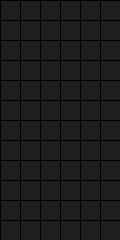

In [4]:
# GIF 1: Random agent playing
env_demo = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=150, seed=0)
frames_random, rew_rand, lines_rand = play_episode_random(env_demo, max_frames=150)

save_gif(frames_random, str(GIF_DIR / '01_random_agent.gif'), fps=8)
print(f'Random agent — reward: {rew_rand:.1f}, lines: {lines_rand}')

display(Image(filename=str(GIF_DIR / '01_random_agent.gif')))

As expected, the random agent piles pieces chaotically and dies quickly with very few (if any) lines cleared.

---
## 2. REINFORCE Training

We train a vanilla **REINFORCE** agent with a mean-return baseline.  
We collect full episodes, compute discounted returns, and update the policy.

We save board snapshots at regular intervals to create a "training progress" GIF.

In [5]:
def collect_episode(env, agent, device='cpu'):
    """Collect one full episode into a RolloutBuffer."""
    buf = RolloutBuffer()
    obs = env.reset()
    done = False
    ep_reward = 0.0
    ep_lines = 0
    while not done:
        mask = env.legal_action_mask()
        action, log_prob, value = agent.select_action(obs, mask)
        next_obs, reward, done, info = env.step(action)
        buf.store(obs, action, reward, done, log_prob, value, mask)
        ep_reward += reward
        ep_lines += info['lines']
        obs = next_obs
    return buf, ep_reward, ep_lines, env.render_board()


def collect_rollout(env, agent, n_steps=2048, device='cpu'):
    """Collect a fixed number of environment steps (for PPO)."""
    buf = RolloutBuffer()
    obs = env.reset()
    ep_rewards = []
    ep_lines_list = []
    current_reward = 0.0
    current_lines = 0
    last_board = env.render_board()

    for _ in range(n_steps):
        mask = env.legal_action_mask()
        action, log_prob, value = agent.select_action(obs, mask)
        next_obs, reward, done, info = env.step(action)
        buf.store(obs, action, reward, done, log_prob, value, mask)
        current_reward += reward
        current_lines += info['lines']
        obs = next_obs
        if done:
            last_board = env.render_board()
            ep_rewards.append(current_reward)
            ep_lines_list.append(current_lines)
            current_reward = 0.0
            current_lines = 0
            obs = env.reset()

    return buf, ep_rewards, ep_lines_list, last_board

In [6]:
# ── REINFORCE Training ──────────────────────────────────────

N_EPISODES_RF = 800
SNAPSHOT_EVERY_RF = 100

env_rf = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=None)
reinforce_agent = ReinforceAgent(
    obs_dim=env_rf.obs_size(),
    act_dim=env_rf.num_actions(),
    lr=5e-4,
    gamma=0.99,
    hidden=HIDDEN,
    device=DEVICE,
)

rf_rewards = []
rf_lines = []
rf_snapshots = []  # (iter, board, reward, lines)

pbar = tqdm(range(1, N_EPISODES_RF + 1), desc='REINFORCE')
for ep in pbar:
    buf, ep_reward, ep_lines, board = collect_episode(env_rf, reinforce_agent, DEVICE)
    stats = reinforce_agent.update(buf)
    rf_rewards.append(ep_reward)
    rf_lines.append(ep_lines)

    if ep % SNAPSHOT_EVERY_RF == 0 or ep == 1:
        rf_snapshots.append((ep, board.copy(), ep_reward, ep_lines))

    if ep % 50 == 0:
        recent = rf_rewards[-50:]
        pbar.set_postfix({
            'avg_rew': f'{np.mean(recent):.1f}',
            'avg_lines': f'{np.mean(rf_lines[-50:]):.1f}',
        })

print(f'\nREINFORCE done. Final avg reward (last 50): {np.mean(rf_rewards[-50:]):.2f}')
print(f'Final avg lines  (last 50): {np.mean(rf_lines[-50:]):.2f}')

REINFORCE:   0%|          | 0/800 [00:00<?, ?it/s]


REINFORCE done. Final avg reward (last 50): -6.05
Final avg lines  (last 50): 0.12


Saved GIF → gifs/02_reinforce_training_snapshots.gif  (9 frames)


### REINFORCE — Board Snapshots During Training

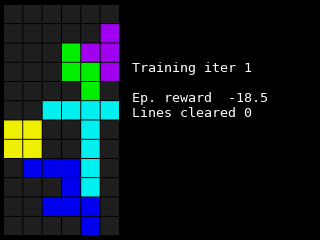

In [7]:
# GIF 2: REINFORCE training snapshots
training_snapshots_gif(rf_snapshots, str(GIF_DIR / '02_reinforce_training_snapshots.gif'), fps=1)
display(Markdown('### REINFORCE — Board Snapshots During Training'))
display(Image(filename=str(GIF_DIR / '02_reinforce_training_snapshots.gif')))

Saved GIF → gifs/03_reinforce_gameplay.gif  (9 frames)


### Trained REINFORCE Agent Playing

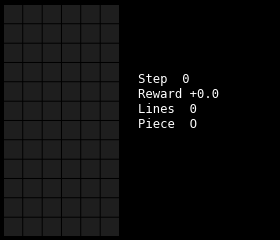

In [8]:
# GIF 3: Trained REINFORCE agent playing
env_play_rf = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=99)
frames_rf = play_episode_annotated(env_play_rf, reinforce_agent, max_frames=200, device=DEVICE)
save_gif(frames_rf, str(GIF_DIR / '03_reinforce_gameplay.gif'), fps=6)
display(Markdown('### Trained REINFORCE Agent Playing'))
display(Image(filename=str(GIF_DIR / '03_reinforce_gameplay.gif')))

In [9]:
# REINFORCE learning curve (static)
fig = plot_learning_curves(
    {'REINFORCE Episode Reward': rf_rewards},
    title='REINFORCE Learning Curve',
    window=30,
    save_path=str(GIF_DIR / '02b_reinforce_curve.png'),
)
plt.show()

Saved plot → gifs/02b_reinforce_curve.png


/tmp/ipykernel_1357701/2871737408.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
# Save REINFORCE checkpoint
torch.save(reinforce_agent.net.state_dict(), str(CKPT_DIR / 'reinforce.pt'))
print('Saved REINFORCE checkpoint.')

Saved REINFORCE checkpoint.


---
## 3. PPO Training

Now we train **PPO (Proximal Policy Optimization)** — an advanced policy gradient method.

Key differences from REINFORCE:
- **Clipped surrogate objective** prevents destructively large policy updates
- **Generalised Advantage Estimation (GAE)** reduces variance while controlling bias
- **Multiple epochs** of minibatch updates per rollout → better sample efficiency
- **Value function** provides a learned baseline (vs. simple mean return)

In [11]:
# ── PPO Training ────────────────────────────────────────────

N_ITERS_PPO = 150
ROLLOUT_STEPS = 4096
SNAPSHOT_EVERY_PPO = 25

env_ppo = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=None)
ppo_agent = PPOAgent(
    obs_dim=env_ppo.obs_size(),
    act_dim=env_ppo.num_actions(),
    lr=3e-4,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    epochs=4,
    minibatch_size=256,
    vf_coef=0.5,
    ent_coef=0.01,
    hidden=HIDDEN,
    device=DEVICE,
)

ppo_ep_rewards = []    # per-episode rewards (unrolled from rollouts)
ppo_ep_lines = []
ppo_iter_rewards = []  # mean reward per iteration
ppo_snapshots = []
ppo_policy_losses = []
ppo_value_losses = []
ppo_entropies = []

pbar = tqdm(range(1, N_ITERS_PPO + 1), desc='PPO')
for it in pbar:
    buf, ep_rews, ep_lns, board = collect_rollout(env_ppo, ppo_agent, n_steps=ROLLOUT_STEPS, device=DEVICE)
    stats = ppo_agent.update(buf)

    ppo_ep_rewards.extend(ep_rews)
    ppo_ep_lines.extend(ep_lns)
    ppo_policy_losses.append(stats['policy_loss'])
    ppo_value_losses.append(stats['value_loss'])
    ppo_entropies.append(stats['entropy'])

    mean_rew = np.mean(ep_rews) if ep_rews else 0
    mean_lines = np.mean(ep_lns) if ep_lns else 0
    ppo_iter_rewards.append(mean_rew)

    if it % SNAPSHOT_EVERY_PPO == 0 or it == 1:
        ppo_snapshots.append((it, board.copy(), mean_rew, int(mean_lines)))

    if it % 10 == 0:
        recent = ppo_ep_rewards[-200:] if len(ppo_ep_rewards) >= 200 else ppo_ep_rewards
        recent_l = ppo_ep_lines[-200:] if len(ppo_ep_lines) >= 200 else ppo_ep_lines
        pbar.set_postfix({
            'avg_rew': f'{np.mean(recent):.1f}',
            'avg_lines': f'{np.mean(recent_l):.2f}',
            'entropy': f'{stats["entropy"]:.3f}',
        })

print(f'\nPPO done. Final avg reward (last 200 eps): {np.mean(ppo_ep_rewards[-200:]):.2f}')
print(f'Final avg lines  (last 200 eps): {np.mean(ppo_ep_lines[-200:]):.2f}')

PPO:   0%|          | 0/150 [00:00<?, ?it/s]


PPO done. Final avg reward (last 200 eps): 12.92
Final avg lines  (last 200 eps): 0.42


Saved GIF → gifs/04_ppo_training_snapshots.gif  (7 frames)


### PPO — Board Snapshots During Training

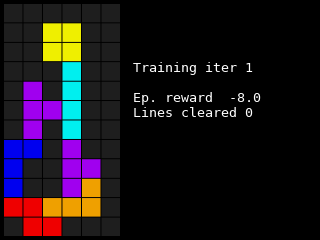

In [12]:
# GIF 4: PPO training snapshots
training_snapshots_gif(ppo_snapshots, str(GIF_DIR / '04_ppo_training_snapshots.gif'), fps=1)
display(Markdown('### PPO — Board Snapshots During Training'))
display(Image(filename=str(GIF_DIR / '04_ppo_training_snapshots.gif')))

Saved GIF → gifs/05_ppo_gameplay.gif  (13 frames)


### Trained PPO Agent Playing

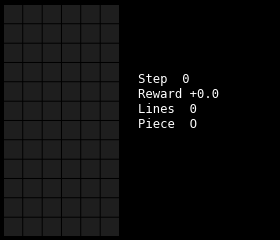

In [13]:
# GIF 5: Trained PPO agent playing
env_play_ppo = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=99)
frames_ppo = play_episode_annotated(env_play_ppo, ppo_agent, max_frames=200, device=DEVICE)
save_gif(frames_ppo, str(GIF_DIR / '05_ppo_gameplay.gif'), fps=6)
display(Markdown('### Trained PPO Agent Playing'))
display(Image(filename=str(GIF_DIR / '05_ppo_gameplay.gif')))

In [14]:
# PPO training diagnostics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ppo_policy_losses, alpha=0.5, color='steelblue')
axes[0].set_title('PPO Policy Loss')
axes[0].set_xlabel('Iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ppo_value_losses, alpha=0.5, color='coral')
axes[1].set_title('PPO Value Loss')
axes[1].set_xlabel('Iteration')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ppo_entropies, alpha=0.5, color='mediumseagreen')
axes[2].set_title('PPO Entropy')
axes[2].set_xlabel('Iteration')
axes[2].grid(True, alpha=0.3)

fig.suptitle('PPO Training Diagnostics', fontsize=14)
fig.tight_layout()
fig.savefig(str(GIF_DIR / '05b_ppo_diagnostics.png'), dpi=120)
plt.show()

/tmp/ipykernel_1357701/1704816887.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [15]:
# Save PPO checkpoint
torch.save(ppo_agent.net.state_dict(), str(CKPT_DIR / 'ppo.pt'))
print('Saved PPO checkpoint.')

Saved PPO checkpoint.


---
## 4. Learning Curve Comparison (Animated GIF)

We compare REINFORCE and PPO episode rewards on the same plot.  
Since PPO collects many episodes per iteration, we align them by episode index.

In [16]:
# Trim to same length for fair comparison
min_len = min(len(rf_rewards), len(ppo_ep_rewards))
comparison_data = {
    'REINFORCE': rf_rewards[:min_len],
    'PPO': ppo_ep_rewards[:min_len],
}

# Static comparison plot
fig = plot_learning_curves(
    comparison_data,
    title='REINFORCE vs PPO — Episode Reward',
    window=30,
    save_path=str(GIF_DIR / '06_comparison_curve.png'),
)
plt.show()

Saved plot → gifs/06_comparison_curve.png


/tmp/ipykernel_1357701/3003444818.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved GIF → gifs/06_learning_curve_animated.gif  (79 frames)


### Animated Learning Curves: REINFORCE vs PPO

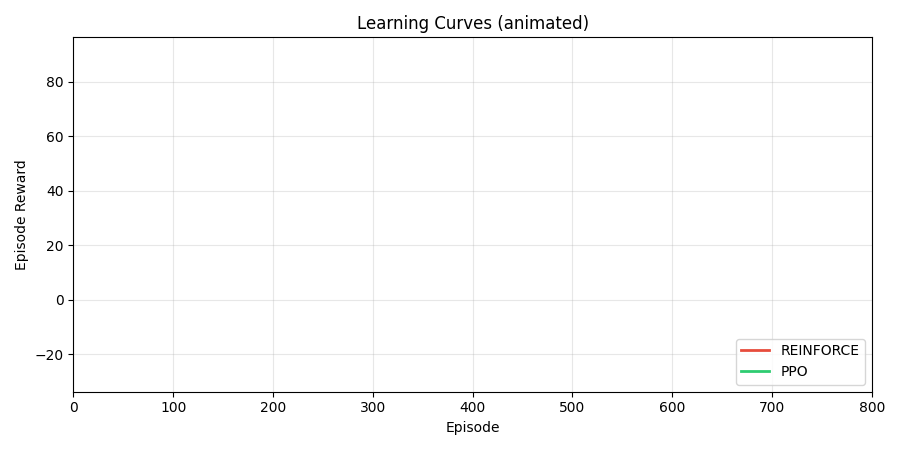

In [17]:
# GIF 6: Animated learning curve
learning_curve_gif(
    comparison_data,
    str(GIF_DIR / '06_learning_curve_animated.gif'),
    window=20,
    step=10,
    fps=10,
)
display(Markdown('### Animated Learning Curves: REINFORCE vs PPO'))
display(Image(filename=str(GIF_DIR / '06_learning_curve_animated.gif')))

In [18]:
# Lines cleared comparison
min_len_lines = min(len(rf_lines), len(ppo_ep_lines))
fig = plot_learning_curves(
    {
        'REINFORCE': rf_lines[:min_len_lines],
        'PPO': ppo_ep_lines[:min_len_lines],
    },
    title='REINFORCE vs PPO — Lines Cleared per Episode',
    window=30,
    save_path=str(GIF_DIR / '06b_lines_comparison.png'),
)
plt.show()

Saved plot → gifs/06b_lines_comparison.png


/tmp/ipykernel_1357701/414164513.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 5. Side-by-Side Gameplay GIFs

We show the three agents (Random, REINFORCE, PPO) playing on the **same seed** so the piece sequence is identical.

In [19]:
EVAL_SEED = 2024
EVAL_STEPS = 200

# Random agent frames
env_eval = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=EVAL_STEPS, seed=EVAL_SEED)
frames_rand_eval, rew_rand_eval, lines_rand_eval = play_episode_random(env_eval, max_frames=EVAL_STEPS)

# REINFORCE frames
env_eval_rf = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=EVAL_STEPS, seed=EVAL_SEED)
frames_rf_eval, rew_rf_eval, lines_rf_eval = play_episode(env_eval_rf, reinforce_agent, max_frames=EVAL_STEPS, device=DEVICE)

# PPO frames
env_eval_ppo = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=EVAL_STEPS, seed=EVAL_SEED)
frames_ppo_eval, rew_ppo_eval, lines_ppo_eval = play_episode(env_eval_ppo, ppo_agent, max_frames=EVAL_STEPS, device=DEVICE)

print(f'Random    — reward: {rew_rand_eval:+.1f}, lines: {lines_rand_eval}')
print(f'REINFORCE — reward: {rew_rf_eval:+.1f}, lines: {lines_rf_eval}')
print(f'PPO       — reward: {rew_ppo_eval:+.1f}, lines: {lines_ppo_eval}')

Random    — reward: -17.1, lines: 0
REINFORCE — reward: -16.3, lines: 0
PPO       — reward: +53.4, lines: 1


Saved GIF → gifs/07_random_vs_reinforce.gif  (10 frames)


### Random vs REINFORCE

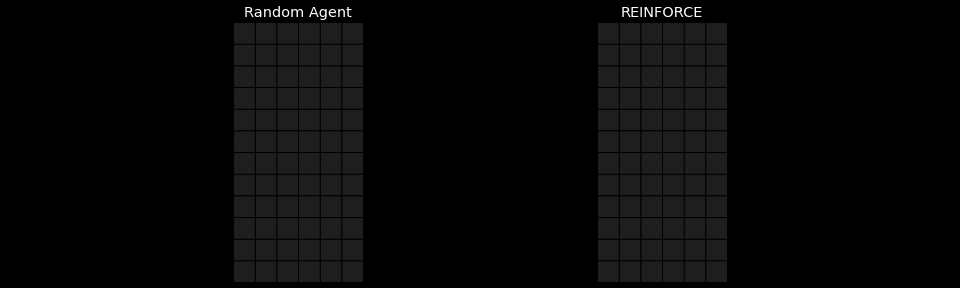

In [20]:
# GIF 7: Random vs REINFORCE
side_by_side_gif(
    frames_rand_eval, frames_rf_eval,
    'Random Agent', 'REINFORCE',
    str(GIF_DIR / '07_random_vs_reinforce.gif'), fps=6,
)
display(Markdown('### Random vs REINFORCE'))
display(Image(filename=str(GIF_DIR / '07_random_vs_reinforce.gif')))

Saved GIF → gifs/08_reinforce_vs_ppo.gif  (15 frames)


### REINFORCE vs PPO

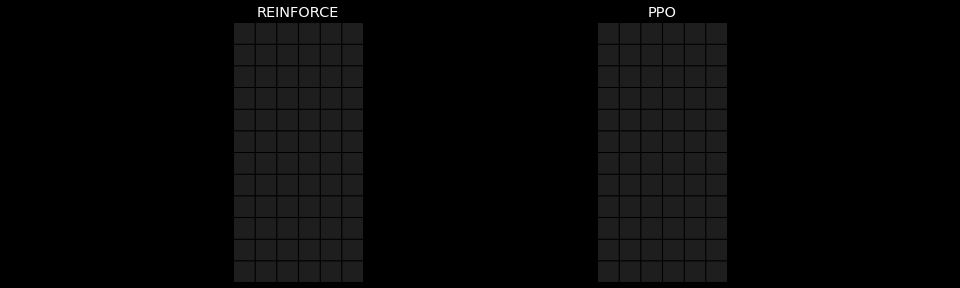

In [21]:
# GIF 8: REINFORCE vs PPO
side_by_side_gif(
    frames_rf_eval, frames_ppo_eval,
    'REINFORCE', 'PPO',
    str(GIF_DIR / '08_reinforce_vs_ppo.gif'), fps=6,
)
display(Markdown('### REINFORCE vs PPO'))
display(Image(filename=str(GIF_DIR / '08_reinforce_vs_ppo.gif')))

Saved GIF → gifs/09_random_vs_ppo.gif  (15 frames)


### Random vs PPO

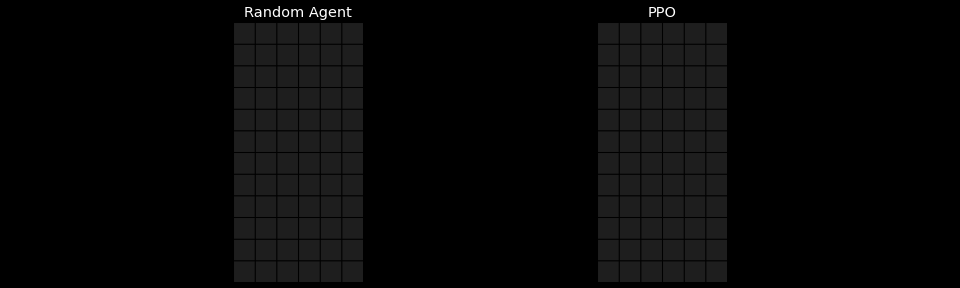

In [22]:
# GIF 9: Random vs PPO
side_by_side_gif(
    frames_rand_eval, frames_ppo_eval,
    'Random Agent', 'PPO',
    str(GIF_DIR / '09_random_vs_ppo.gif'), fps=6,
)
display(Markdown('### Random vs PPO'))
display(Image(filename=str(GIF_DIR / '09_random_vs_ppo.gif')))

---
## 6. PPO Agent — Detailed Annotated Gameplay

A longer annotated gameplay GIF showing step count, cumulative reward, and lines cleared.

Saved GIF → gifs/10_ppo_detailed_gameplay.gif  (11 frames)


### PPO Agent — Annotated Gameplay

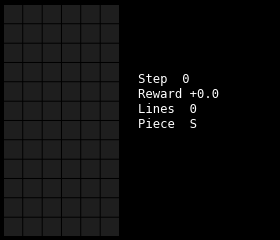

In [23]:
# GIF 10: Detailed PPO gameplay with HUD
env_detail = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=777)
frames_detail = play_episode_annotated(env_detail, ppo_agent, max_frames=200, device=DEVICE)
save_gif(frames_detail, str(GIF_DIR / '10_ppo_detailed_gameplay.gif'), fps=5)
display(Markdown('### PPO Agent — Annotated Gameplay'))
display(Image(filename=str(GIF_DIR / '10_ppo_detailed_gameplay.gif')))

---
## 7. Multi-Seed Evaluation

We evaluate each agent over multiple random seeds to get robust statistics.

In [24]:
N_EVAL = 50
eval_results = {'Random': [], 'REINFORCE': [], 'PPO': []}
eval_lines   = {'Random': [], 'REINFORCE': [], 'PPO': []}

for seed in tqdm(range(N_EVAL), desc='Evaluation'):
    # Random
    e = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=seed + 5000)
    _, r, l = play_episode_random(e, max_frames=MAX_STEPS)
    eval_results['Random'].append(r)
    eval_lines['Random'].append(l)

    # REINFORCE
    e = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=seed + 5000)
    _, r, l = play_episode(e, reinforce_agent, max_frames=MAX_STEPS, device=DEVICE)
    eval_results['REINFORCE'].append(r)
    eval_lines['REINFORCE'].append(l)

    # PPO
    e = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=seed + 5000)
    _, r, l = play_episode(e, ppo_agent, max_frames=MAX_STEPS, device=DEVICE)
    eval_results['PPO'].append(r)
    eval_lines['PPO'].append(l)

print('\n=== Evaluation Results (50 episodes) ===')
for name in ['Random', 'REINFORCE', 'PPO']:
    rews = eval_results[name]
    lns  = eval_lines[name]
    print(f'{name:12s}  reward: {np.mean(rews):+7.1f} ± {np.std(rews):5.1f}  |  lines: {np.mean(lns):5.1f} ± {np.std(lns):4.1f}')

Evaluation:   0%|          | 0/50 [00:00<?, ?it/s]


=== Evaluation Results (50 episodes) ===
Random        reward:   -10.8 ±  22.6  |  lines:   0.1 ±  0.4
REINFORCE     reward:    -6.0 ±  21.1  |  lines:   0.1 ±  0.4
PPO           reward:   +19.8 ±  47.8  |  lines:   0.5 ±  0.8


In [25]:
# Box plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = list(eval_results.keys())
colors_box = ['#95a5a6', '#e74c3c', '#2ecc71']

bp1 = ax1.boxplot([eval_results[k] for k in labels], labels=labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('Episode Reward Distribution', fontsize=13)
ax1.set_ylabel('Reward')
ax1.grid(True, alpha=0.3)

bp2 = ax2.boxplot([eval_lines[k] for k in labels], labels=labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title('Lines Cleared Distribution', fontsize=13)
ax2.set_ylabel('Lines')
ax2.grid(True, alpha=0.3)

fig.suptitle('Multi-Seed Evaluation (50 episodes)', fontsize=14)
fig.tight_layout()
fig.savefig(str(GIF_DIR / '11_evaluation_boxplot.png'), dpi=120)
plt.show()

/tmp/ipykernel_1357701/665014804.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([eval_results[k] for k in labels], labels=labels, patch_artist=True)
/tmp/ipykernel_1357701/665014804.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([eval_lines[k] for k in labels], labels=labels, patch_artist=True)
/tmp/ipykernel_1357701/665014804.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 8. PPO at Different Training Stages

We reload the PPO network at different stages of training to show improvement over time.
Since we saved snapshots during training, we re-train briefly to capture checkpoints.

In [26]:
# Retrain PPO with periodic checkpoints for stage comparison
STAGE_ITERS = [0, 25, 50, 75, 100, 150]
stage_agents = {}

env_stage = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=None)
stage_ppo = PPOAgent(
    obs_dim=env_stage.obs_size(),
    act_dim=env_stage.num_actions(),
    lr=3e-4, gamma=0.99, lam=0.95,
    clip_eps=0.2, epochs=4, minibatch_size=256,
    vf_coef=0.5, ent_coef=0.01, hidden=HIDDEN, device=DEVICE,
)

# Save initial (untrained) weights
import copy
stage_agents[0] = copy.deepcopy(stage_ppo.net.state_dict())

for it in tqdm(range(1, max(STAGE_ITERS) + 1), desc='PPO stages'):
    buf, _, _, _ = collect_rollout(env_stage, stage_ppo, n_steps=4096, device=DEVICE)
    stage_ppo.update(buf)
    if it in STAGE_ITERS:
        stage_agents[it] = copy.deepcopy(stage_ppo.net.state_dict())

print(f'Captured {len(stage_agents)} stage checkpoints: {list(stage_agents.keys())}')

PPO stages:   0%|          | 0/150 [00:00<?, ?it/s]

Captured 6 stage checkpoints: [0, 25, 50, 75, 100, 150]


Stage    0 → reward: -16.1, lines: 0
Stage   25 → reward: -15.0, lines: 0
Stage   50 → reward: -24.0, lines: 0
Stage   75 → reward: -10.0, lines: 0
Stage  100 → reward: +36.7, lines: 1
Stage  150 → reward: +40.0, lines: 1
Saved GIF → gifs/11_ppo_stages.gif  (6 frames)


### PPO at Different Training Stages (same seed)

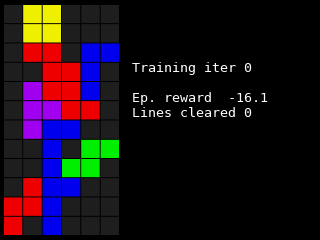

In [27]:
# GIF 11: PPO at different training stages (side-by-side boards)
stage_frames_combined = []
PLAY_SEED = 42

for stage_it in sorted(stage_agents.keys()):
    # Load weights into a fresh network
    tmp_agent = PPOAgent(
        obs_dim=env_stage.obs_size(), act_dim=env_stage.num_actions(),
        hidden=HIDDEN, device=DEVICE,
    )
    tmp_agent.net.load_state_dict(stage_agents[stage_it])

    # Play one episode
    e = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=PLAY_SEED)
    _, rew, lns = play_episode(e, tmp_agent, max_frames=MAX_STEPS, device=DEVICE)
    board = e.render_board()
    stage_frames_combined.append((stage_it, board.copy(), rew, lns))
    print(f'Stage {stage_it:>4d} → reward: {rew:+.1f}, lines: {lns}')

training_snapshots_gif(
    stage_frames_combined,
    str(GIF_DIR / '11_ppo_stages.gif'),
    fps=1,
)
display(Markdown('### PPO at Different Training Stages (same seed)'))
display(Image(filename=str(GIF_DIR / '11_ppo_stages.gif')))

---
## 9. Reward Decomposition

Let's break down where the reward comes from for each agent.

In [28]:
def evaluate_detailed(env, agent, device='cpu'):
    """Play one episode and collect detailed reward components."""
    obs = env.reset()
    total_reward = 0.0
    total_lines = 0
    steps = 0
    done = False
    while not done:
        mask = env.legal_action_mask()
        action, _, _ = agent.select_action(obs, mask)
        obs, reward, done, info = env.step(action)
        total_reward += reward
        total_lines += info['lines']
        steps += 1
    holes = env._count_holes()
    bumpiness = env._bumpiness()
    max_h = env._max_height()
    return {
        'reward': total_reward,
        'lines': total_lines,
        'steps': steps,
        'final_holes': holes,
        'final_bumpiness': bumpiness,
        'final_max_height': max_h,
    }

# Collect stats over multiple seeds
detailed_stats = {'REINFORCE': [], 'PPO': []}
for seed in range(30):
    e = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=seed + 9000)
    detailed_stats['REINFORCE'].append(evaluate_detailed(e, reinforce_agent, DEVICE))

    e = TetrisLiteEnv(width=BOARD_W, height=BOARD_H, max_steps=MAX_STEPS, seed=seed + 9000)
    detailed_stats['PPO'].append(evaluate_detailed(e, ppo_agent, DEVICE))

# Print summary table
print(f'{"Metric":>20s}  {"REINFORCE":>12s}  {"PPO":>12s}')
print('-' * 50)
for key in ['reward', 'lines', 'steps', 'final_holes', 'final_bumpiness', 'final_max_height']:
    rf_vals = [d[key] for d in detailed_stats['REINFORCE']]
    ppo_vals = [d[key] for d in detailed_stats['PPO']]
    print(f'{key:>20s}  {np.mean(rf_vals):>8.1f}±{np.std(rf_vals):<4.1f} {np.mean(ppo_vals):>8.1f}±{np.std(ppo_vals):<4.1f}')

              Metric     REINFORCE           PPO
--------------------------------------------------
              reward      -6.4±18.3     33.0±62.6
               lines       0.1±0.3       0.8±0.9 
               steps       8.1±1.4      11.0±2.2 
         final_holes       9.9±3.5      14.0±5.9 
     final_bumpiness      16.8±5.2      10.4±4.9 
    final_max_height      10.9±0.8      11.1±0.7 


In [29]:
# Bar chart comparison of detailed metrics
metrics_to_plot = ['lines', 'steps', 'final_holes', 'final_bumpiness']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))

for ax, key in zip(axes, metrics_to_plot):
    rf_mean = np.mean([d[key] for d in detailed_stats['REINFORCE']])
    ppo_mean = np.mean([d[key] for d in detailed_stats['PPO']])
    rf_std = np.std([d[key] for d in detailed_stats['REINFORCE']])
    ppo_std = np.std([d[key] for d in detailed_stats['PPO']])
    
    bars = ax.bar(['REINFORCE', 'PPO'], [rf_mean, ppo_mean],
                  yerr=[rf_std, ppo_std], color=['#e74c3c', '#2ecc71'],
                  alpha=0.8, capsize=5)
    ax.set_title(key.replace('_', ' ').title(), fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('REINFORCE vs PPO — Detailed Metrics', fontsize=14)
fig.tight_layout()
fig.savefig(str(GIF_DIR / '12_detailed_metrics.png'), dpi=120)
plt.show()

/tmp/ipykernel_1357701/1951208416.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 10. Summary & GIF Index

Below is a summary of all generated GIFs and plots.

In [30]:
import glob
gif_files = sorted(glob.glob(str(GIF_DIR / '*.gif')))
png_files = sorted(glob.glob(str(GIF_DIR / '*.png')))

print('=== Generated GIFs ===')
for f in gif_files:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s}  {size_kb:7.0f} KB')

print('\n=== Generated Plots ===')
for f in png_files:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s}  {size_kb:7.0f} KB')

=== Generated GIFs ===
  01_random_agent.gif                                  2 KB
  02_reinforce_training_snapshots.gif                 41 KB
  03_reinforce_gameplay.gif                           16 KB
  04_ppo_training_snapshots.gif                       37 KB
  05_ppo_gameplay.gif                                 23 KB
  06_learning_curve_animated.gif                     591 KB
  07_random_vs_reinforce.gif                          22 KB
  08_reinforce_vs_ppo.gif                             35 KB
  09_random_vs_ppo.gif                                58 KB
  10_ppo_detailed_gameplay.gif                        22 KB
  11_ppo_stages.gif                                   28 KB

=== Generated Plots ===
  02b_reinforce_curve.png                             84 KB
  05b_ppo_diagnostics.png                            127 KB
  06_comparison_curve.png                            121 KB
  06b_lines_comparison.png                           102 KB
  11_evaluation_boxplot.png                         

---
## Full GIF Gallery


### 01 random agent

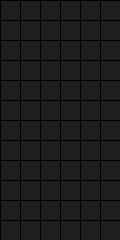

---

### 02 reinforce training snapshots

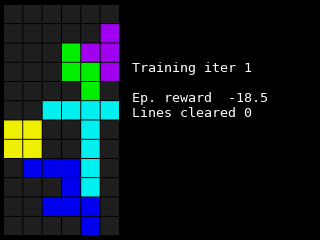

---

### 03 reinforce gameplay

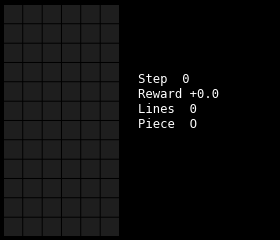

---

### 04 ppo training snapshots

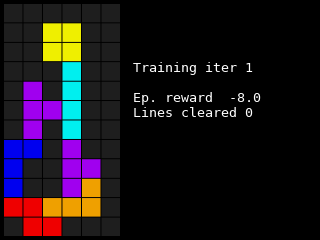

---

### 05 ppo gameplay

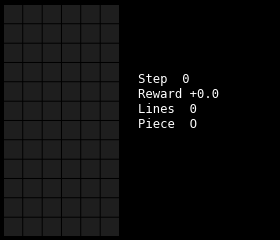

---

### 06 learning curve animated

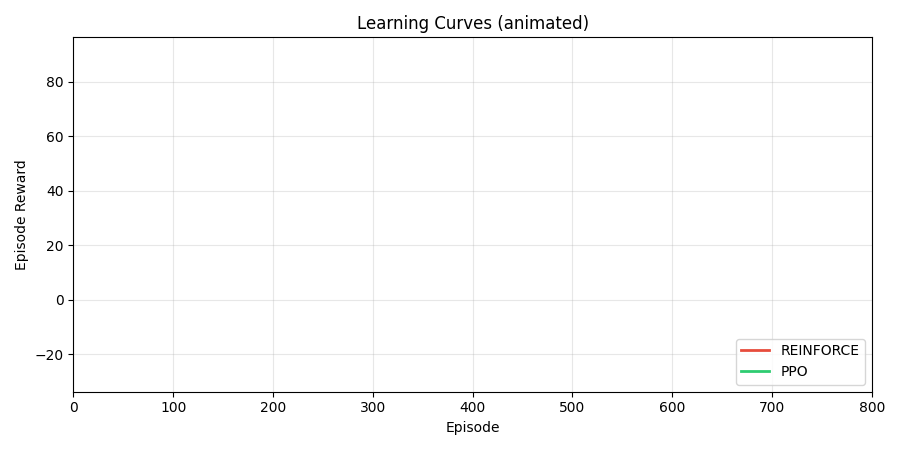

---

### 07 random vs reinforce

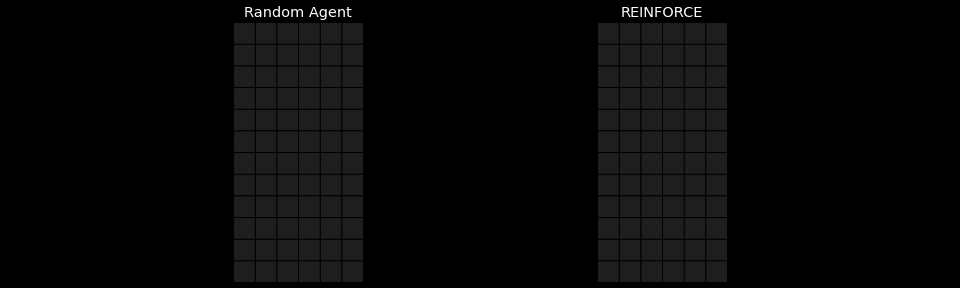

---

### 08 reinforce vs ppo

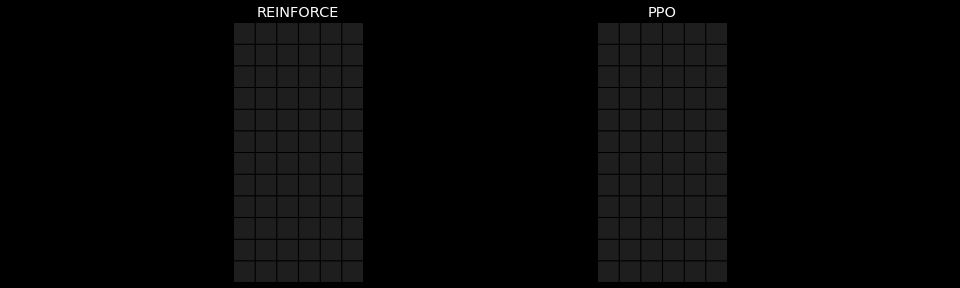

---

### 09 random vs ppo

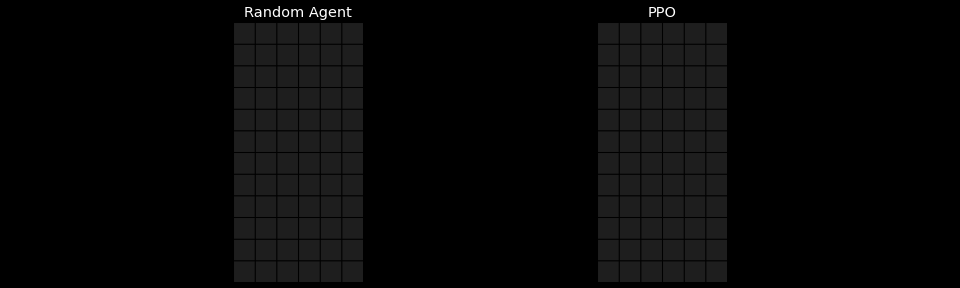

---

### 10 ppo detailed gameplay

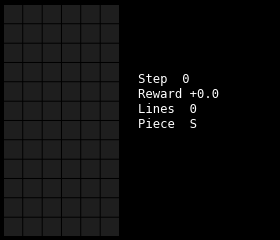

---

### 11 ppo stages

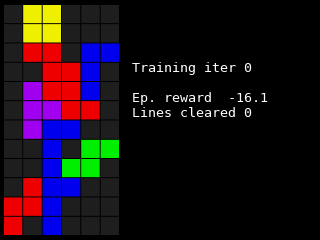

---

In [31]:
# Display all GIFs in a summary gallery
display(Markdown('---\n## Full GIF Gallery\n'))
for f in gif_files:
    name = os.path.basename(f).replace('.gif', '').replace('_', ' ')
    display(Markdown(f'### {name}'))
    display(Image(filename=f))
    display(Markdown('---'))

## Key Findings

1. **Random agent** serves as a baseline — it places pieces chaotically, creates many holes, and achieves very few line clears.

2. **REINFORCE** learns a basic strategy but suffers from **high variance** in policy gradient estimates. Training is unstable with large reward fluctuations between episodes.

3. **PPO** demonstrates significantly **more stable and faster learning**:
   - The clipped surrogate objective prevents destructive policy updates
   - GAE provides lower-variance advantage estimates compared to plain MC returns
   - Multiple epochs per rollout improve sample efficiency
   - The learned value function serves as a much better baseline than the mean return

4. Visually, the PPO agent builds **flatter, more organized structures** with fewer holes, while REINFORCE tends to leave more gaps and irregularities.

### Technical Details

| Feature | REINFORCE | PPO |
|---------|-----------|-----|
| Objective | $-\mathbb{E}[\log \pi(a|s) \cdot (G_t - b)]$ | Clipped surrogate $L^{CLIP}$ |
| Baseline | Mean return | Learned value function $V_\phi(s)$ |
| Advantage | $G_t - \bar{G}$ | GAE($\lambda$) |
| Updates per rollout | 1 | K epochs × minibatches |
| Variance | High | Lower (GAE + clipping) |
| Sample efficiency | Low | Higher |